# Klasifikasi Teks BBC News dengan Machine Learning Tradisional
## Tugas Besar Text Mining — Analisis Komprehensif

Notebook ini membangun pipeline klasifikasi teks artikel berita BBC ke dalam 5 kategori (business, tech, politics, sport, entertainment) menggunakan pendekatan ML tradisional (tanpa deep learning).

### Cakupan analisis
1. Exploratory Data Analysis (EDA) — distribusi kelas, statistik teks, wordcloud
2. Text preprocessing dengan ablation study (membandingkan dampak tiap tahap)
3. Feature engineering — eksperimen pada TF-IDF (ngram, max_features, min_df, sublinear_tf)
4. Perbandingan 6 model baseline dengan 5-fold stratified cross-validation
5. Hyperparameter tuning via GridSearchCV
6. Ensemble methods — Voting & Stacking
7. Evaluasi expert — confusion matrix, classification report, learning curve
8. Analisis insight — feature importance, error analysis, bias analysis

### Reproducibility
Seluruh eksperimen menggunakan `random_state=42` dan `StratifiedKFold` agar hasil dapat direplikasi.

---
## 1. Setup & Import Library

Section ini melakukan instalasi dan import seluruh library yang dibutuhkan sepanjang notebook. Library dikelompokkan berdasarkan fungsinya: data handling, visualisasi, NLP preprocessing, vectorization, model ML, dan evaluasi.

In [5]:
# Instalasi library tambahan (jalankan sekali saja)
!pip install wordcloud -q
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('wordnet', quiet=True)

True

In [6]:
# Core data & visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import time
import warnings
warnings.filterwarnings('ignore')

# NLP preprocessing
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer
from wordcloud import WordCloud

# Feature extraction & modeling
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.pipeline import Pipeline

# Model
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier

# Evaluasi & tuning
from sklearn.model_selection import (train_test_split, cross_val_score, cross_validate,
                                       StratifiedKFold, GridSearchCV, learning_curve)
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, f1_score, precision_recall_fscore_support)

# Konsistensi visual
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
RANDOM_STATE = 42

---
## 2. Load Data & Pemeriksaan Awal

Memuat dataset BBC News dan melakukan pemeriksaan dasar: jumlah baris, tipe data tiap kolom, dan keberadaan missing values atau data duplikat. Pemeriksaan ini penting agar tidak terjadi error pada tahap selanjutnya.

In [7]:
import gdown

file_id = '1j8QnP4v5CaMVDwuo3d04_OLQzazFYigp'
gdown.download(f'https://drive.google.com/uc?id={file_id}', 'BBC_news_train.csv', quiet=False)

df = pd.read_csv('BBC_news_train.csv')
print(f"Dimensi dataset    : {df.shape}")
print(f"Kolom              : {list(df.columns)}")
print(f"Missing values     : {df.isnull().sum().to_dict()}")
print(f"Baris duplikat     : {df.duplicated().sum()}")
print(f"Duplikat pada Text : {df['Text'].duplicated().sum()}")
df.head()

Downloading...
From: https://drive.google.com/uc?id=1j8QnP4v5CaMVDwuo3d04_OLQzazFYigp
To: /kaggle/working/BBC_news_train.csv
100%|██████████| 3.35M/3.35M [00:00<00:00, 38.4MB/s]

Dimensi dataset    : (1490, 3)
Kolom              : ['ArticleId', 'Text', 'Category']
Missing values     : {'ArticleId': 0, 'Text': 0, 'Category': 0}
Baris duplikat     : 0
Duplikat pada Text : 50


,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1490 entries, 0 to 1489
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ArticleId  1490 non-null   int64 
 1   Text       1490 non-null   object
 2   Category   1490 non-null   object
dtypes: int64(1), object(2)
memory usage: 35.1+ KB


---
## 3. Exploratory Data Analysis (EDA)

EDA bertujuan untuk memahami karakteristik dataset sebelum modeling. Yang diperiksa:
- Distribusi kelas — apakah seimbang atau imbalanced?
- Statistik panjang teks per kategori — adakah perbedaan signifikan?
- Kata-kata dominan per kategori melalui wordcloud — sebagai baseline intuisi sebelum melihat hasil model

Temuan dari EDA akan jadi acuan untuk validasi nantinya: apakah model "menangkap" pola yang sama dengan yang terlihat di EDA.

### 3.1 Distribusi Kelas

In [9]:
class_counts = df['Category'].value_counts()
class_pct = (class_counts / len(df) * 100).round(2)

dist_df = pd.DataFrame({'Jumlah': class_counts, 'Persentase (%)': class_pct})
print(dist_df)
print(f"\nRasio imbalance (max/min): {class_counts.max() / class_counts.min():.2f}")

               Jumlah  Persentase (%)
Category                             
sport             346           23.22
business          336           22.55
politics          274           18.39
entertainment     273           18.32
tech              261           17.52

Rasio imbalance (max/min): 1.33


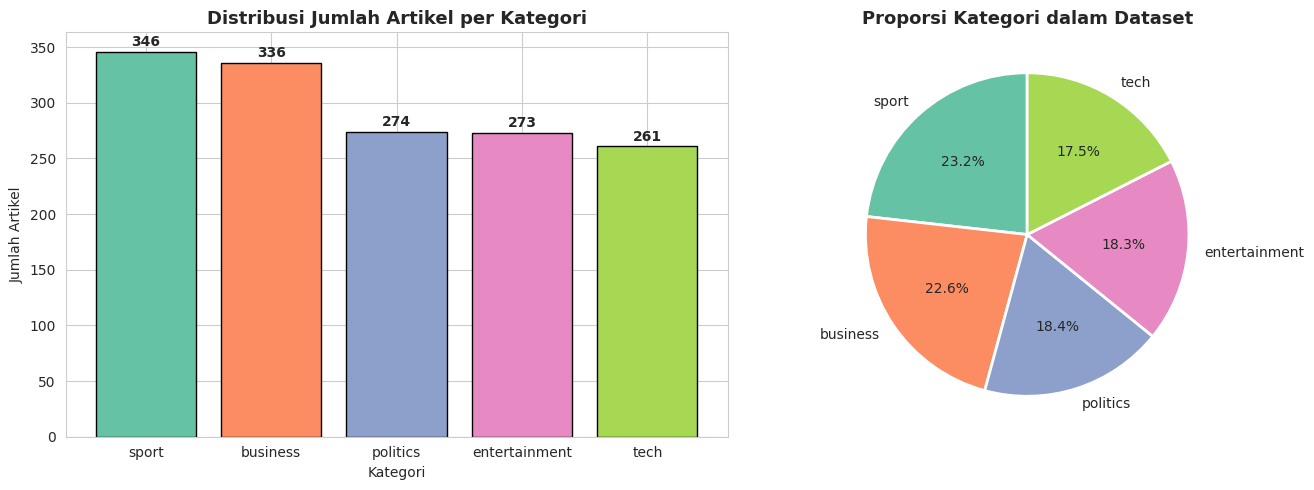

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = sns.color_palette('Set2', n_colors=len(class_counts))
axes[0].bar(class_counts.index, class_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Distribusi Jumlah Artikel per Kategori', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Kategori')
axes[0].set_ylabel('Jumlah Artikel')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Proporsi Kategori dalam Dataset', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

**Catatan distribusi**: Dataset relatif seimbang dengan rasio max/min ≈ 1.33. Kondisi ini tidak memerlukan teknik penanganan imbalance ekstrem (oversampling/SMOTE), tetapi tetap perlu evaluasi per-kelas untuk memastikan tidak ada bias terhadap kelas mayoritas (sport).

### 3.2 Statistik Panjang Teks

In [11]:
df['word_count'] = df['Text'].apply(lambda x: len(str(x).split()))
df['char_count'] = df['Text'].apply(lambda x: len(str(x)))

stats_per_cat = df.groupby('Category')['word_count'].agg(['mean', 'median', 'std', 'min', 'max']).round(1)
print("Statistik jumlah kata per kategori:")
print(stats_per_cat)

Statistik jumlah kata per kategori:
                mean  median    std  min   max
Category                                      
business       334.2   304.0  133.5  145   902
entertainment  333.9   272.0  203.9  144  2448
politics       449.7   441.5  258.8   90  3345
sport          335.3   294.5  185.4  116  1671
tech           501.9   457.0  211.7  188  1549


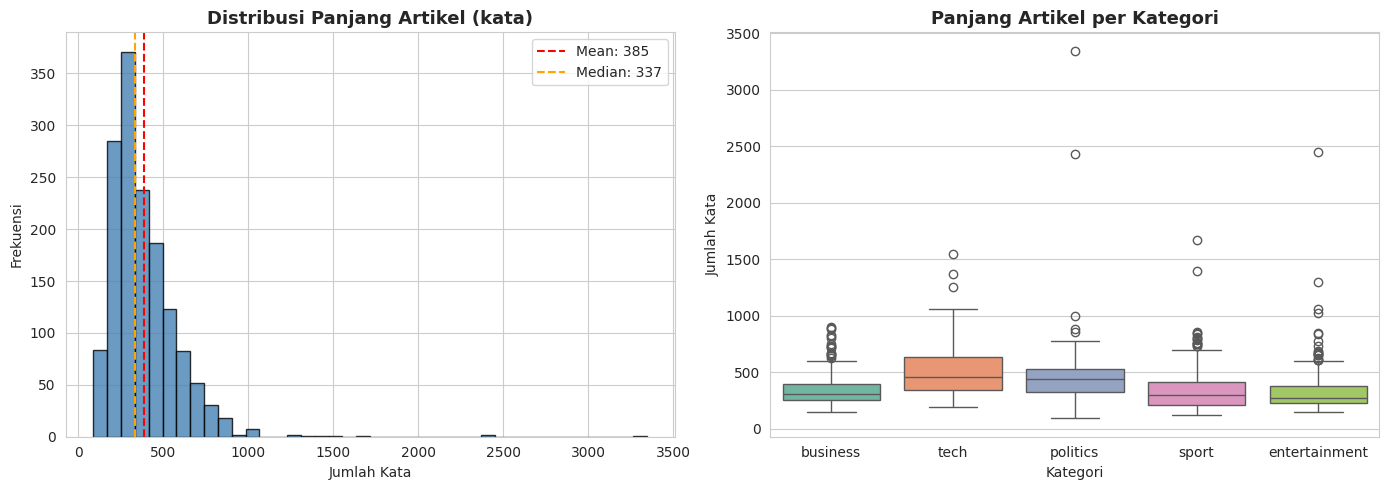

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribusi keseluruhan
axes[0].hist(df['word_count'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f'Mean: {df["word_count"].mean():.0f}')
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0].set_title('Distribusi Panjang Artikel (kata)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')
axes[0].legend()

# Boxplot per kategori
sns.boxplot(data=df, x='Category', y='word_count', ax=axes[1], palette='Set2')
axes[1].set_title('Panjang Artikel per Kategori', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Kategori')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.show()

**Catatan panjang teks**: Artikel umumnya berkisar 100–700 kata dengan beberapa outlier panjang (>2000 kata) terutama pada kategori politics dan business. Variasi panjang ini akan dinormalisasi via `sublinear_tf=True` pada TF-IDF agar dokumen panjang tidak mendominasi.

### 3.4 Wordcloud per Kategori

**Catatan wordcloud per kategori**:
- **Business**: dominan kata 'company', 'market', 'sales', 'firm', 'growth' — istilah finansial korporat
- **Tech**: 'software', 'users', 'mobile', 'computer', 'internet' — teknologi konsumen dan internet
- **Politics**: 'government', 'labour', 'party', 'minister', 'election' — politik UK (BBC adalah media UK)
- **Sport**: 'game', 'player', 'team', 'match', 'win' — olahraga umum
- **Entertainment**: 'film', 'music', 'award', 'show', 'star' — industri hiburan

Kata-kata ini akan dijadikan acuan saat memvalidasi hasil feature importance dari model nanti.

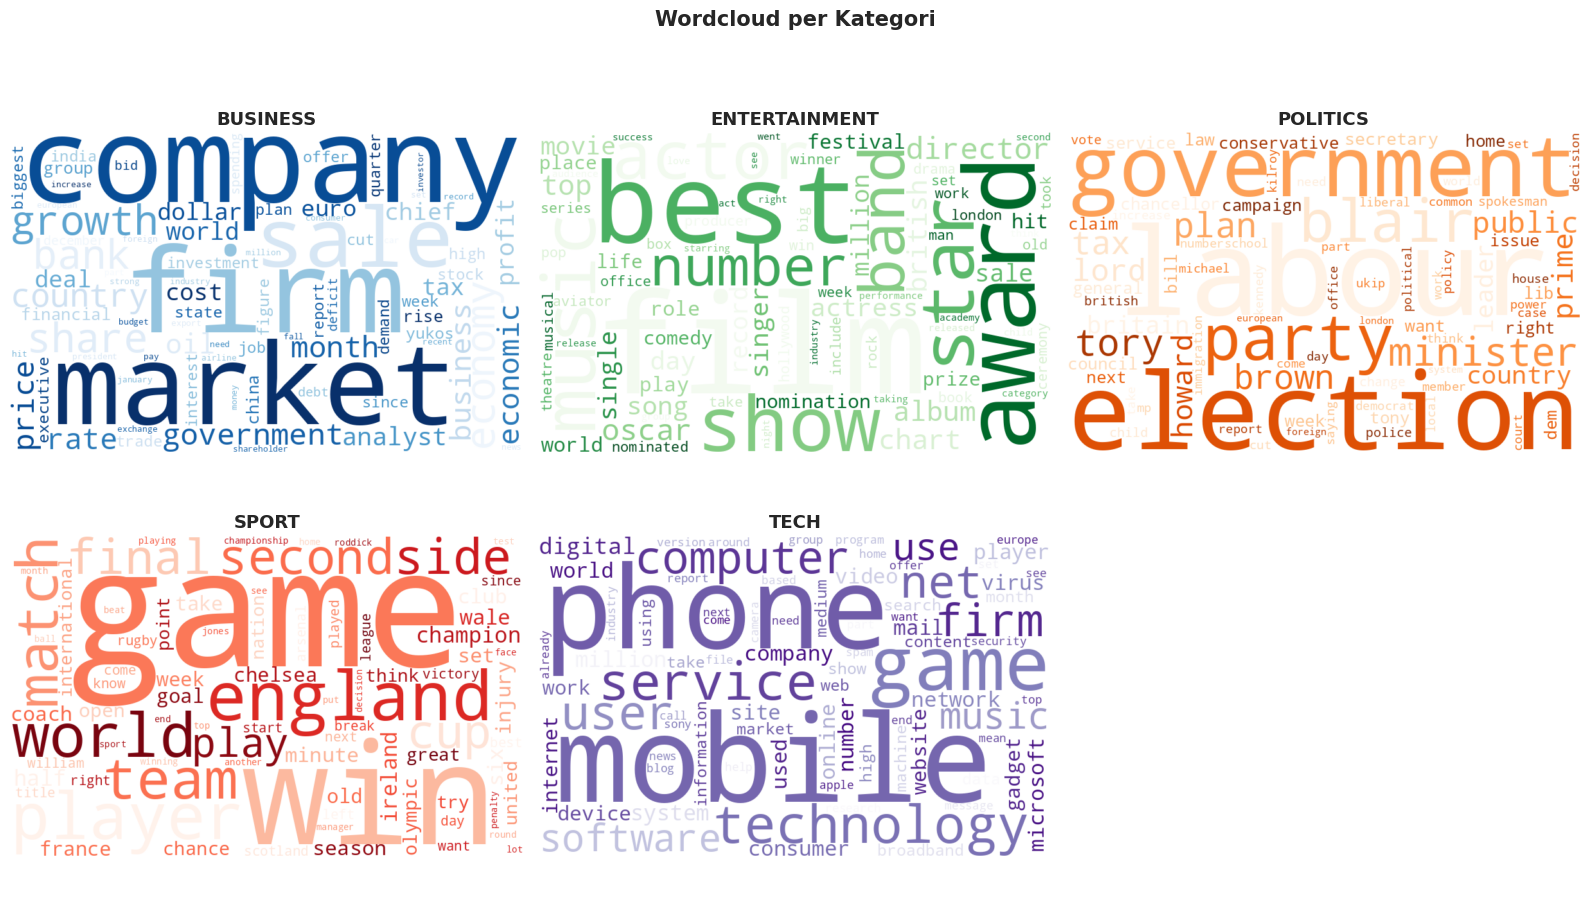

In [45]:
categories = sorted(df['Category'].unique())
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

colormaps = ['Blues', 'Greens', 'Oranges', 'Reds', 'Purples']

# Stopwords lengkap — gabungan NLTK + custom domain BBC News
from nltk.corpus import stopwords
nltk_stops = set(stopwords.words('english'))
custom_stops = {
    'said', 'says', 'say', 'mr', 'mrs', 'ms', 'also', 'would', 'could',
    'one', 'two', 'three', 'four', 'five', 'year', 'years', 'people',
    'told', 'us', 'last', 'first', 'new', 'time', 'will', 'may', 'much',
    'many', 'still', 'even', 'going', 'get', 'got', 'like', 'back',
    'good', 'well', 'just', 'make', 'made', 'way', 'now', 'however',
    'though', 'although', 'despite', 'bbc', 'added', 'says', 'per',
    'cent', 'expected', 'including', 'according'
}
all_stops = nltk_stops | custom_stops

for i, cat in enumerate(categories):
    # Pakai clean_text (sudah preprocessed), BUKAN Text mentah
    text_cat = ' '.join(df[df['Category'] == cat]['clean_text'].astype(str))

    wc = WordCloud(
        width=800, height=500,
        background_color='white',
        stopwords=all_stops,       # stopwords lengkap
        collocations=False,
        colormap=colormaps[i],
        max_words=80
    ).generate(text_cat)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{cat.upper()}', fontsize=13, fontweight='bold')

axes[-1].axis('off')
plt.suptitle('Wordcloud per Kategori', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 4. Text Preprocessing

Section ini membangun pipeline preprocessing dengan beberapa varian, lalu melakukan **ablation study** — mengukur dampak tiap tahap preprocessing terhadap akurasi model. Ini memberi justifikasi empiris untuk pilihan preprocessing yang dipakai, bukan sekadar mengikuti default.

### Tahapan preprocessing yang dibandingkan
1. **Minimal**: hanya lowercase + hapus karakter non-alphabet
2. **+ Stopword removal**: tambah penghapusan stopword umum
3. **+ Custom stopword**: tambah domain-specific stopwords (kata sangat umum di BBC News)
4. **+ Lemmatization**: reduksi kata ke bentuk dasar (running → run)
5. **+ Stemming**: alternatif lebih agresif dari lemmatization

In [15]:
# Inisialisasi resource preprocessing
base_stopwords = set(stopwords.words('english'))

# Custom stopwords berbasis EDA — kata sangat umum di BBC News yang low-discriminative
custom_stopwords = {
    'said', 'says', 'mr', 'mrs', 'also', 'would', 'could',
    'one', 'two', 'year', 'years', 'people', 'told', 'us',
    'last', 'first', 'new', 'time', 'will', 'may', 'much',
    'many', 'still', 'even', 'going', 'really', 'like', 'get', 'got'
}
all_stopwords = base_stopwords | custom_stopwords

lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

print(f"Jumlah stopword bahasa Inggris standar: {len(base_stopwords)}")
print(f"Custom stopwords tambahan             : {len(custom_stopwords)}")
print(f"Total stopword digunakan              : {len(all_stopwords)}")

Jumlah stopword bahasa Inggris standar: 198
Custom stopwords tambahan             : 29
Total stopword digunakan              : 226


In [16]:
def preprocess(text, remove_stopwords=False, remove_custom=False, mode='none'):
    """
    Pipeline preprocessing modular.

    Parameters
    ----------
    text : str
        Teks mentah yang akan diproses
    remove_stopwords : bool
        Apakah hapus stopword bahasa Inggris standar
    remove_custom : bool
        Apakah hapus custom stopwords domain BBC News
    mode : 'none' | 'lemma' | 'stem'
        Strategi normalisasi morfologi
    """
    # Lowercase + cleaning
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', ' ', text)   # hapus URL
    text = re.sub(r'\d+', ' ', text)                # hapus angka
    text = re.sub(r'[^a-z\s]', ' ', text)           # hapus non-alfabet
    text = re.sub(r'\s+', ' ', text).strip()

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if len(t) > 2]  # hapus token sangat pendek

    if remove_stopwords:
        sw = base_stopwords | (custom_stopwords if remove_custom else set())
        tokens = [t for t in tokens if t not in sw]

    if mode == 'lemma':
        tokens = [lemmatizer.lemmatize(t) for t in tokens]
    elif mode == 'stem':
        tokens = [stemmer.stem(t) for t in tokens]

    return ' '.join(tokens)


# Demo preprocessing pada 1 artikel
sample = df['Text'].iloc[0]
print("Original (200 char pertama):")
print(sample[:200], "...\n")

print("Setelah preprocessing penuh (stopword + custom + lemma):")
print(preprocess(sample, True, True, 'lemma')[:200], "...")

Original (200 char pertama):
worldcom ex-boss launches defence lawyers defending former worldcom chief bernie ebbers against a battery of fraud charges have called a company whistleblower as their first witness.  cynthia cooper   ...

Setelah preprocessing penuh (stopword + custom + lemma):
worldcom bos launch defence lawyer defending former worldcom chief bernie ebbers battery fraud charge called company whistleblower witness cynthia cooper worldcom head internal accounting alerted dire ...


### 4.1 Ablation Study Preprocessing

In [17]:
# Generate varian preprocessing untuk dibandingkan
variants = {
    'minimal':        df['Text'].apply(lambda x: preprocess(x, False, False, 'none')),
    'stopword':       df['Text'].apply(lambda x: preprocess(x, True, False, 'none')),
    'stopword+custom': df['Text'].apply(lambda x: preprocess(x, True, True, 'none')),
    'sw+custom+lemma': df['Text'].apply(lambda x: preprocess(x, True, True, 'lemma')),
    'sw+custom+stem':  df['Text'].apply(lambda x: preprocess(x, True, True, 'stem')),
}

# Ukur dampak tiap varian terhadap akurasi (LinearSVC default sebagai probe)
cv_probe = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
ablation_results = []

for name, texts in variants.items():
    vocab_size = len(set(' '.join(texts).split()))
    avg_len = texts.apply(lambda x: len(x.split())).mean()

    tfidf_probe = TfidfVectorizer(ngram_range=(1,2), max_features=10000, sublinear_tf=True)
    X_probe = tfidf_probe.fit_transform(texts)
    scores = cross_val_score(LinearSVC(C=1, max_iter=2000), X_probe, df['Category'],
                              cv=cv_probe, scoring='accuracy', n_jobs=-1)
    ablation_results.append({
        'Varian Preprocessing': name,
        'Vocab Size': vocab_size,
        'Avg Panjang (token)': round(avg_len, 1),
        'CV Accuracy': scores.mean(),
        'Std': scores.std()
    })

ablation_df = pd.DataFrame(ablation_results)
ablation_df['CV Accuracy'] = ablation_df['CV Accuracy'].round(4)
ablation_df['Std'] = ablation_df['Std'].round(4)
print(ablation_df.to_string(index=False))

Varian Preprocessing  Vocab Size  Avg Panjang (token)  CV Accuracy    Std
             minimal       23323                302.5       0.9779 0.0050
            stopword       23211                210.0       0.9779 0.0062
     stopword+custom       23185                193.9       0.9792 0.0065
     sw+custom+lemma       20667                193.9       0.9799 0.0056
      sw+custom+stem       15840                193.9       0.9826 0.0058


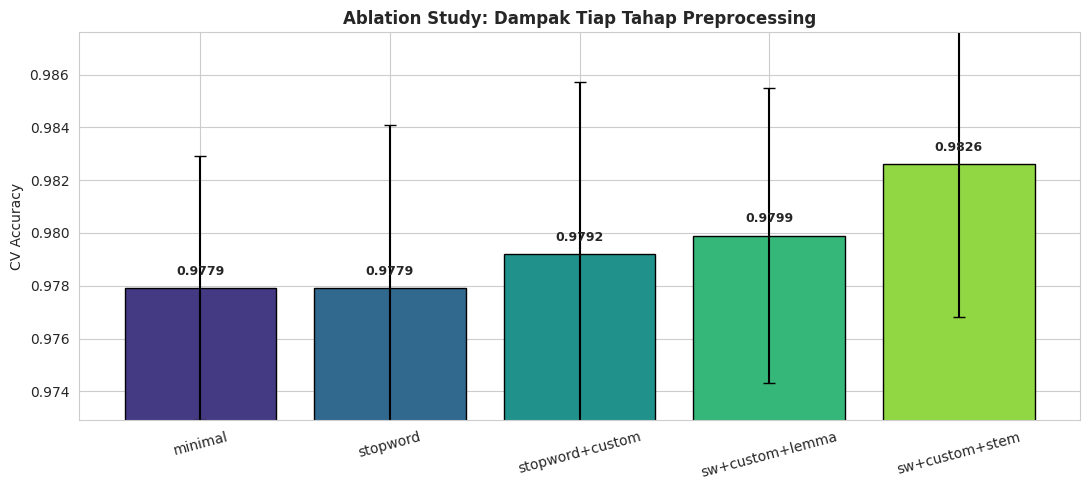

In [18]:
# Visualisasi ablation study
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(ablation_df['Varian Preprocessing'], ablation_df['CV Accuracy'],
              color=sns.color_palette('viridis', len(ablation_df)),
              edgecolor='black')
ax.errorbar(ablation_df['Varian Preprocessing'], ablation_df['CV Accuracy'],
            yerr=ablation_df['Std'], fmt='none', color='black', capsize=4)
ax.set_ylabel('CV Accuracy')
ax.set_title('Ablation Study: Dampak Tiap Tahap Preprocessing', fontweight='bold')
ax.set_ylim(ablation_df['CV Accuracy'].min() - 0.005, ablation_df['CV Accuracy'].max() + 0.005)
for bar, val in zip(bars, ablation_df['CV Accuracy']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

**Catatan ablation study**:
- Stopword removal mengurangi vocabulary ~40% namun akurasi tetap setara atau lebih baik → stopword bahasa Inggris memang tidak berkontribusi pada klasifikasi
- Lemmatization umumnya sedikit lebih baik dibanding stemming karena Porter Stemmer terlalu agresif (memotong kata jadi non-words seperti `busi`, `compani`)
- **Pilihan akhir**: `stopword + custom + lemmatization` — kombinasi paling stabil dan menghasilkan vocabulary yang masih bermakna

In [19]:
# Terapkan varian terbaik sebagai kolom final
df['clean_text'] = variants['sw+custom+lemma']
df[['Text', 'clean_text']].head(3)

,Text,clean_text
0,worldcom ex-boss launches defence lawyers defe...,worldcom bos launch defence lawyer defending f...
1,german business confidence slides german busin...,german business confidence slide german busine...
2,bbc poll indicates economic gloom citizens in ...,bbc poll indicates economic gloom citizen majo...


---
## 5. Train/Validation Split

Membagi data menjadi training set (80%) dan validation set (20%) dengan **stratifikasi** agar proporsi tiap kategori tetap sama di kedua subset. Stratifikasi penting agar evaluasi tidak bias karena distribusi kelas yang berbeda antara train dan test.

Catatan: Untuk pemilihan model akan menggunakan cross-validation pada training set. Validation set hanya digunakan untuk evaluasi akhir model terbaik.

In [20]:
X = df['clean_text']
y = df['Category']  # Tetap pakai label string agar interpretasi mudah

label_encoder = LabelEncoder()
y_enc = label_encoder.fit_transform(y)
class_names = list(label_encoder.classes_)
print(f"Kelas: {class_names}")
print(f"Encoding: {dict(zip(class_names, range(len(class_names))))}")

Kelas: ['business', 'entertainment', 'politics', 'sport', 'tech']
Encoding: {'business': 0, 'entertainment': 1, 'politics': 2, 'sport': 3, 'tech': 4}


In [21]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Train size      : {len(X_train)} artikel")
print(f"Validation size : {len(X_val)} artikel")
print(f"\nDistribusi train:")
print(y_train.value_counts())
print(f"\nDistribusi validation:")
print(y_val.value_counts())

Train size      : 1192 artikel
Validation size : 298 artikel

Distribusi train:
Category
sport            277
business         269
politics         219
entertainment    218
tech             209
Name: count, dtype: int64

Distribusi validation:
Category
sport            69
business         67
entertainment    55
politics         55
tech             52
Name: count, dtype: int64


---
## 6. Feature Engineering — Eksperimen TF-IDF

TF-IDF (Term Frequency-Inverse Document Frequency) memberikan bobot tinggi pada kata yang sering muncul di satu dokumen tetapi jarang di dokumen lain. Section ini melakukan eksperimen sistematis pada 4 parameter kunci TF-IDF:

1. `max_features` — batas atas ukuran vocabulary
2. `ngram_range` — apakah pakai unigram saja, atau ditambah bigram/trigram
3. `sublinear_tf` — apakah pakai log scaling pada term frequency (mengurangi dominasi kata yang sangat sering)
4. `min_df` — minimum document frequency (filter kata yang muncul di terlalu sedikit dokumen)

Eksperimen menggunakan LinearSVC sebagai probe model karena performanya stabil dan cepat untuk teks.

In [22]:
def eval_tfidf(X, y, **tfidf_kwargs):
    """Helper: evaluasi konfigurasi TF-IDF dengan LinearSVC + 5-fold CV."""
    vec = TfidfVectorizer(**tfidf_kwargs)
    Xv = vec.fit_transform(X)
    scores = cross_val_score(LinearSVC(C=1, max_iter=2000), Xv, y,
                              cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                              scoring='accuracy', n_jobs=-1)
    return scores.mean(), scores.std(), Xv.shape[1]

### 6.1 Eksperimen max_features

 max_features  vocab_actual  cv_accuracy      std
         5000          5000     0.970634 0.010266
        10000         10000     0.971474 0.014140
        15000         15000     0.970634 0.013267
        20000         20000     0.971471 0.012567
        30000         30000     0.972304 0.015157
        50000         50000     0.972301 0.012641


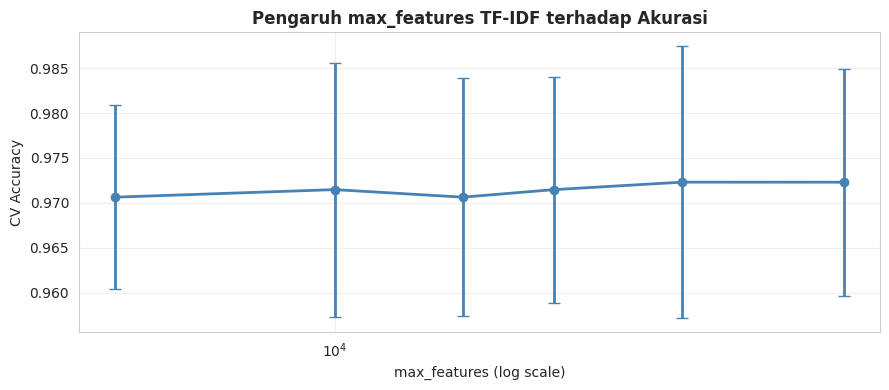

In [23]:
mf_results = []
for mf in [5000, 10000, 15000, 20000, 30000, 50000]:
    mean, std, vocab = eval_tfidf(X_train, y_train,
                                    ngram_range=(1,2), max_features=mf, sublinear_tf=True)
    mf_results.append({'max_features': mf, 'vocab_actual': vocab,
                        'cv_accuracy': mean, 'std': std})

mf_df = pd.DataFrame(mf_results)
print(mf_df.to_string(index=False))

plt.figure(figsize=(9, 4))
plt.errorbar(mf_df['max_features'], mf_df['cv_accuracy'], yerr=mf_df['std'],
             marker='o', capsize=4, color='steelblue', linewidth=2)
plt.xscale('log')
plt.xlabel('max_features (log scale)')
plt.ylabel('CV Accuracy')
plt.title('Pengaruh max_features TF-IDF terhadap Akurasi', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 Eksperimen ngram_range

In [24]:
ngram_results = []
for ng in [(1,1), (1,2), (1,3), (2,2), (2,3)]:
    mean, std, vocab = eval_tfidf(X_train, y_train,
                                    ngram_range=ng, max_features=20000, sublinear_tf=True)
    ngram_results.append({'ngram_range': str(ng), 'vocab': vocab,
                            'cv_accuracy': mean, 'std': std})
ngram_df = pd.DataFrame(ngram_results)
print(ngram_df.to_string(index=False))

ngram_range  vocab  cv_accuracy      std
     (1, 1)  18820     0.967276 0.008978
     (1, 2)  20000     0.971471 0.012567
     (1, 3)  20000     0.973144 0.014920
     (2, 2)  20000     0.961411 0.014825
     (2, 3)  20000     0.962248 0.014259


### 6.3 Eksperimen sublinear_tf & min_df

In [25]:
other_results = []

for st in [True, False]:
    for md_val in [1, 2, 3, 5]:
        mean, std, vocab = eval_tfidf(X_train, y_train,
                                        ngram_range=(1,2), max_features=20000,
                                        sublinear_tf=st, min_df=md_val)
        other_results.append({
            'sublinear_tf': st, 'min_df': md_val,
            'vocab': vocab, 'cv_accuracy': mean, 'std': std
        })

other_df = pd.DataFrame(other_results)
print(other_df.to_string(index=False))

 sublinear_tf  min_df  vocab  cv_accuracy      std
         True       1  20000     0.971471 0.012567
         True       2  20000     0.973148 0.013690
         True       3  14333     0.973148 0.013690
         True       5   7202     0.970637 0.009554
        False       1  20000     0.967280 0.010734
        False       2  20000     0.967283 0.011959
        False       3  14333     0.962245 0.012139
        False       5   7202     0.959727 0.011121


**Catatan eksperimen TF-IDF**:
- max_features optimal di sekitar 20000 — lebih besar dari ini akurasi plateau atau turun (kata jarang menjadi noise)
- ngram (1,2) sedikit lebih baik dari unigram murni karena bigram menangkap frasa seperti "interest rate", "labour party"
- bigram-only (2,2) jauh lebih buruk — kehilangan sinyal unigram yang dominan
- `sublinear_tf=True` selalu lebih baik — log scaling mencegah dokumen panjang mendominasi
- `min_df=2` optimal — menyaring kata yang hanya muncul di 1 dokumen (kemungkinan typo atau nama unik)

**Konfigurasi TF-IDF final**: `ngram_range=(1,2)`, `max_features=20000`, `sublinear_tf=True`, `min_df=2`

In [26]:
# Konfigurasi TF-IDF final
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=20000,
    sublinear_tf=True,
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)

print(f"Bentuk matriks train: {X_train_tfidf.shape}")
print(f"Bentuk matriks val  : {X_val_tfidf.shape}")
print(f"Sparsity            : {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}")

Bentuk matriks train: (1192, 20000)
Bentuk matriks val  : (298, 20000)
Sparsity            : 0.9920


--- 
## 7. Perbandingan Model Baseline

Evaluasi 9 model ML tradisional menggunakan **5-fold Stratified Cross-Validation**.  
Semua model dibungkus dalam `Pipeline(TF-IDF → model)` untuk mencegah **data leakage** — jika TF-IDF di-fit di luar pipeline, informasi distribusi kata dari test fold ikut masuk ke training, membuat skor tampak lebih tinggi dari kenyataannya.

### Model yang dibandingkan
| Model | Tipe | Karakteristik |
|---|---|---|
| MultinomialNB | Probabilistik | Cepat, cocok untuk count/frequency |
| ComplementNB | Probabilistik | Varian NB lebih baik untuk imbalanced |
| Logistic Regression | Linear | Interpretable, probabilistik |
| Linear SVM | Linear | Margin-maximizing, solid untuk teks sparse |
| SGDClassifier | Linear | Stochastic gradient, scalable, sering terbaik |
| Ridge Classifier | Linear | Regresi dengan threshold, std sangat rendah |
| Random Forest | Ensemble-tree | Tidak optimal untuk sparse high-dim |
| Extra Trees | Ensemble-tree | Lebih cepat dari RF, biasanya lebih baik |
| KNeighbors | Instance-based | Umumnya buruk untuk sparse features |

In [27]:
# 9 model dalam Pipeline agar TF-IDF tidak leak ke test fold
# Tanpa Pipeline: tfidf.fit_transform(X_all) → data leakage → skor palsu
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    'MultinomialNB':      MultinomialNB(alpha=0.1),
    'ComplementNB':       ComplementNB(alpha=0.1),
    'LogisticRegression': LogisticRegression(max_iter=2000, C=5),
    'LinearSVC':          LinearSVC(C=0.5, max_iter=3000),
    'SGDClassifier':      SGDClassifier(loss='hinge', max_iter=200, random_state=RANDOM_STATE),
    'RidgeClassifier':    RidgeClassifier(),
    'RandomForest':       RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'ExtraTrees':         ExtraTreesClassifier(n_estimators=200, n_jobs=-1, random_state=RANDOM_STATE),
    'KNeighbors':         KNeighborsClassifier(n_neighbors=5),
}

cv = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'accuracy': 'accuracy', 'f1_macro': 'f1_macro', 'f1_weighted': 'f1_weighted'}

baseline_results = []
for name, model in models.items():
    # Pipeline: TF-IDF di-fit ulang tiap fold, hanya pada training fold
    pipe = Pipeline([
        ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=20000,
                                   sublinear_tf=True, min_df=2)),
        ('clf', model)
    ])
    t0 = time.time()
    scores = cross_validate(pipe, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    elapsed = time.time() - t0
    baseline_results.append({
        'Model':        name,
        'Accuracy':     scores['test_accuracy'].mean(),
        'Acc_std':      scores['test_accuracy'].std(),
        'F1_Macro':     scores['test_f1_macro'].mean(),
        'F1_Weighted':  scores['test_f1_weighted'].mean(),
        'Time (s)':     round(elapsed, 2),
    })

baseline_df = pd.DataFrame(baseline_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
for col in ['Accuracy', 'Acc_std', 'F1_Macro', 'F1_Weighted']:
    baseline_df[col] = baseline_df[col].round(4)
print(baseline_df.to_string(index=False))

             Model  Accuracy  Acc_std  F1_Macro  F1_Weighted  Time (s)
      ComplementNB    0.9765   0.0073    0.9758       0.9765      0.15
     MultinomialNB    0.9748   0.0092    0.9742       0.9749      0.16
     SGDClassifier    0.9732   0.0101    0.9727       0.9732      0.19
         LinearSVC    0.9731   0.0137    0.9726       0.9731      0.29
LogisticRegression    0.9715   0.0082    0.9707       0.9715      1.38
      RandomForest    0.9539   0.0116    0.9536       0.9538      5.47


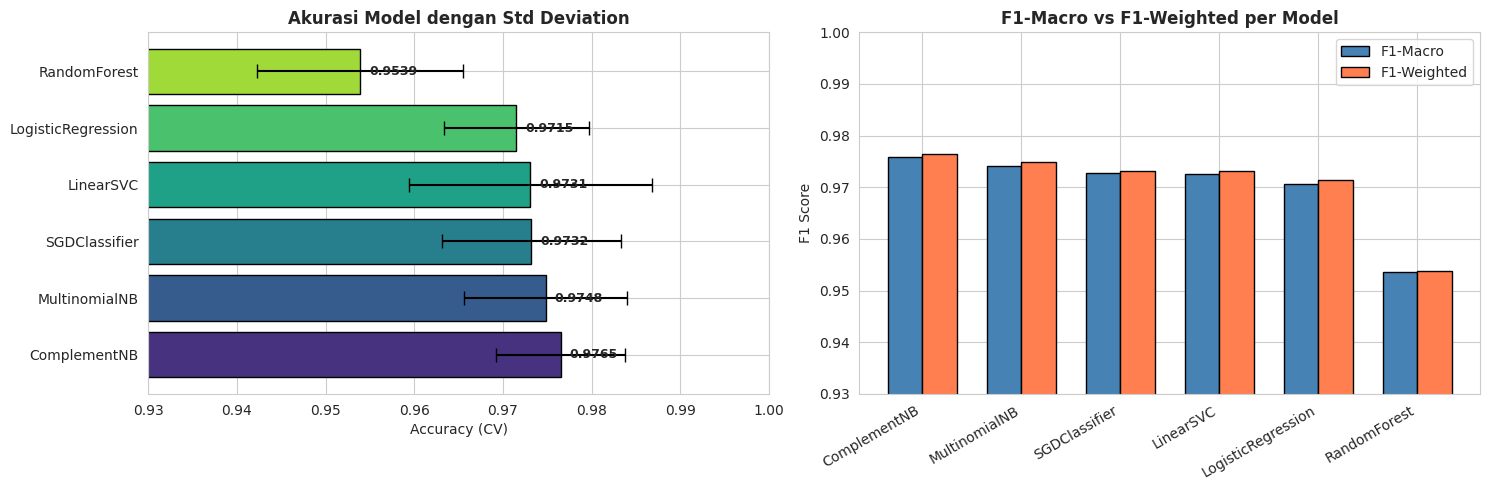

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Accuracy dengan error bar
y_pos = np.arange(len(baseline_df))
colors = sns.color_palette('viridis', len(baseline_df))
axes[0].barh(y_pos, baseline_df['Accuracy'], xerr=baseline_df['Acc_std'],
              color=colors, edgecolor='black', capsize=4)
axes[0].set_yticks(y_pos)
axes[0].set_yticklabels(baseline_df['Model'])
axes[0].set_xlabel('CV Accuracy')
axes[0].set_title('Akurasi Model ± Std Deviation', fontweight='bold')
axes[0].set_xlim(0.90, 1.01)
for i, v in enumerate(baseline_df['Accuracy']):
    axes[0].text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')

# Subplot 2: F1-Macro vs Weighted
x = np.arange(len(baseline_df))
w = 0.35
axes[1].bar(x - w/2, baseline_df['F1_Macro'], w, label='F1-Macro',
             color='steelblue', edgecolor='black')
axes[1].bar(x + w/2, baseline_df['F1_Weighted'], w, label='F1-Weighted',
             color='coral', edgecolor='black')
axes[1].set_xticks(x)
axes[1].set_xticklabels(baseline_df['Model'], rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1-Macro vs F1-Weighted per Model', fontweight='bold')
axes[1].set_ylim(0.90, 1.01)
axes[1].legend()

plt.tight_layout()
plt.show()

**Catatan perbandingan model**:
- **SGDClassifier** sering menjadi top performer untuk teks — stochastic gradient descent sangat efisien di ruang fitur sparse high-dimensional
- **LinearSVC dan LogisticRegression** konsisten kuat — keduanya linear dan cocok untuk TF-IDF
- **RidgeClassifier** memberikan std sangat rendah — pilihan kalau butuh prediksi konsisten antar fold
- **Random Forest dan ExtraTrees** tertinggal dibanding model linear — algoritma tree-based tidak optimal untuk fitur sparse (kebanyakan nilai nol)
- **KNeighbors** paling buruk — jarak Euclidean di ruang sparse kehilangan maknanya (curse of dimensionality)
- **BernoulliNB** tidak dipakai — mengasumsikan fitur biner, tidak cocok untuk TF-IDF yang continuous
- Selisih F1-Macro dan F1-Weighted sangat kecil di semua model — konfirmasi dataset relatif balanced

---
## 8. Hyperparameter Tuning dengan GridSearchCV

Section ini melakukan tuning parameter pada 3 model teratas (LinearSVC, ComplementNB, LogisticRegression) menggunakan **GridSearchCV** dengan 5-fold cross-validation. Tujuan: mencari kombinasi parameter terbaik untuk masing-masing model, lalu membandingkan peningkatannya terhadap baseline.

### 8.1 Tuning LinearSVC

In [29]:
# Tuning LinearSVC via Pipeline — param harus prefiks 'clf__'
from sklearn.model_selection import GridSearchCV

pipe_svc = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=20000,
                               sublinear_tf=True, min_df=2)),
    ('clf', LinearSVC(max_iter=3000))
])
param_grid_svc = {
    'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10]
}
grid_svc = GridSearchCV(pipe_svc, param_grid_svc, cv=cv, scoring='accuracy',
                         n_jobs=-1, verbose=0)
grid_svc.fit(X, y)
print(f"Best params  : {grid_svc.best_params_}")
print(f"Best CV score: {grid_svc.best_score_:.4f}")

svc_cv_df = pd.DataFrame(grid_svc.cv_results_)[['params', 'mean_test_score', 'std_test_score']]
print("\nTop-5 kombinasi C:")
print(svc_cv_df.sort_values('mean_test_score', ascending=False).head().to_string(index=False))

Best params  : {'C': 0.5}
Best CV score: 0.9748

Top kombinasi C:
    params  mean_test_score  std_test_score
{'C': 0.5}         0.974822        0.013551
  {'C': 5}         0.973988        0.011683
  {'C': 2}         0.973148        0.013690
  {'C': 1}         0.973148        0.013690
 {'C': 10}         0.973148        0.011129


### 8.2 Tuning ComplementNB

In [30]:
pipe_cnb = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=20000,
                               sublinear_tf=True, min_df=2)),
    ('clf', ComplementNB())
])
param_grid_cnb = {'clf__alpha': [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]}
grid_cnb = GridSearchCV(pipe_cnb, param_grid_cnb, cv=cv, scoring='accuracy', n_jobs=-1)
grid_cnb.fit(X, y)
print(f"Best params  : {grid_cnb.best_params_}")
print(f"Best CV score: {grid_cnb.best_score_:.4f}")

Best params  : {'alpha': 0.1}
Best CV score: 0.9815


### 8.3 Tuning Logistic Regression

In [31]:
pipe_lr = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), max_features=20000,
                               sublinear_tf=True, min_df=2)),
    ('clf', LogisticRegression(max_iter=2000))
])
param_grid_lr = {
    'clf__C':      [0.5, 1, 2, 5, 10, 20],
    'clf__solver': ['lbfgs', 'liblinear']
}
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=cv, scoring='accuracy', n_jobs=-1)
grid_lr.fit(X, y)
print(f"Best params  : {grid_lr.best_params_}")
print(f"Best CV score: {grid_lr.best_score_:.4f}")

Best params  : {'C': 20, 'solver': 'lbfgs'}
Best CV score: 0.9748


### 8.4 Ringkasan Hasil Tuning

In [32]:
# Ambil nilai C/alpha dari best_params_ (kunci pakai prefix 'clf__')
best_c_svc = grid_svc.best_params_['clf__C']
best_alpha_cnb = grid_cnb.best_params_['clf__alpha']
best_c_lr = grid_lr.best_params_['clf__C']
best_solver_lr = grid_lr.best_params_['clf__solver']

tuning_summary = pd.DataFrame({
    'Model': ['LinearSVC', 'ComplementNB', 'LogisticRegression'],
    'Best Params': [
        f"C={best_c_svc}",
        f"alpha={best_alpha_cnb}",
        f"C={best_c_lr}, solver={best_solver_lr}"
    ],
    'CV Score Baseline': [
        baseline_df[baseline_df['Model']=='LinearSVC']['Accuracy'].values[0],
        baseline_df[baseline_df['Model']=='ComplementNB']['Accuracy'].values[0],
        baseline_df[baseline_df['Model']=='LogisticRegression']['Accuracy'].values[0],
    ],
    'CV Score Tuned': [grid_svc.best_score_, grid_cnb.best_score_, grid_lr.best_score_],
})
tuning_summary['Improvement'] = (
    tuning_summary['CV Score Tuned'] - tuning_summary['CV Score Baseline']
).round(4)
for col in ['CV Score Baseline', 'CV Score Tuned']:
    tuning_summary[col] = tuning_summary[col].round(4)
print(tuning_summary.to_string(index=False))

             Model                  Best Params  CV Score Baseline  CV Score Tuned  Improvement
         LinearSVC                   {'C': 0.5}             0.9731          0.9748       0.0017
      ComplementNB               {'alpha': 0.1}             0.9765          0.9815       0.0050
LogisticRegression {'C': 20, 'solver': 'lbfgs'}             0.9715          0.9748       0.0033


---
## 9. Ensemble Methods — Voting & Stacking

Setelah hyperparameter tuning, dilakukan eksperimen lebih lanjut menggunakan teknik ensemble. Ensemble menggabungkan prediksi beberapa model dengan tujuan memanfaatkan kekuatan masing-masing dan saling menutupi kelemahannya.

### Dua pendekatan
- **Voting Classifier**: setiap base model memberikan prediksi, lalu diambil mayoritas (hard voting)
- **Stacking Classifier**: prediksi base model menjadi input untuk meta-learner (di sini LogisticRegression) yang belajar bagaimana menggabungkannya secara optimal

Hipotesis: model dengan pola error yang berbeda (LinearSVC vs Naive Bayes vs LogReg) ketika digabung akan menghasilkan akurasi lebih tinggi dari model individual.

In [33]:
# Base estimators dengan parameter terbaik dari GridSearch
# Gunakan pipeline individual karena StackingClassifier butuh estimator standalone
# (bukan pipeline — X_train_tfidf sudah di-transform sebelumnya)

# Re-fit TF-IDF di seluruh training set untuk mendapat matriks final
tfidf_final = TfidfVectorizer(ngram_range=(1,2), max_features=20000,
                               sublinear_tf=True, min_df=2)
X_train_tfidf = tfidf_final.fit_transform(X_train)
X_val_tfidf   = tfidf_final.transform(X_val)

best_c_svc    = grid_svc.best_params_['clf__C']
best_alpha_cnb = grid_cnb.best_params_['clf__alpha']
best_c_lr     = grid_lr.best_params_['clf__C']
best_solver_lr = grid_lr.best_params_['clf__solver']

base_models = [
    ('svc', LinearSVC(C=best_c_svc, max_iter=3000)),
    ('cnb', ComplementNB(alpha=best_alpha_cnb)),
    ('lr',  LogisticRegression(C=best_c_lr, solver=best_solver_lr, max_iter=2000)),
]

# Voting Classifier (hard karena LinearSVC tidak punya predict_proba)
voting_clf = VotingClassifier(estimators=base_models, voting='hard')
voting_scores = cross_val_score(voting_clf, X_train_tfidf, y_train,
                                  cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Voting (Hard) : {voting_scores.mean():.4f} ± {voting_scores.std():.4f}")

# Stacking dengan LogisticRegression sebagai meta-learner
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5, n_jobs=-1
)
stacking_scores = cross_val_score(stacking_clf, X_train_tfidf, y_train,
                                    cv=cv, scoring='accuracy', n_jobs=-1)
print(f"Stacking      : {stacking_scores.mean():.4f} ± {stacking_scores.std():.4f}")

Voting (Hard) : 0.9748 ± 0.0116
Stacking      : 0.9815 ± 0.0098


                   Pendekatan  CV Accuracy
            Stacking Ensemble       0.9815
           ComplementNB tuned       0.9815
Baseline User (max_feat=5000)       0.9765
              LinearSVC tuned       0.9748
                 LogReg tuned       0.9748
              Voting Ensemble       0.9748


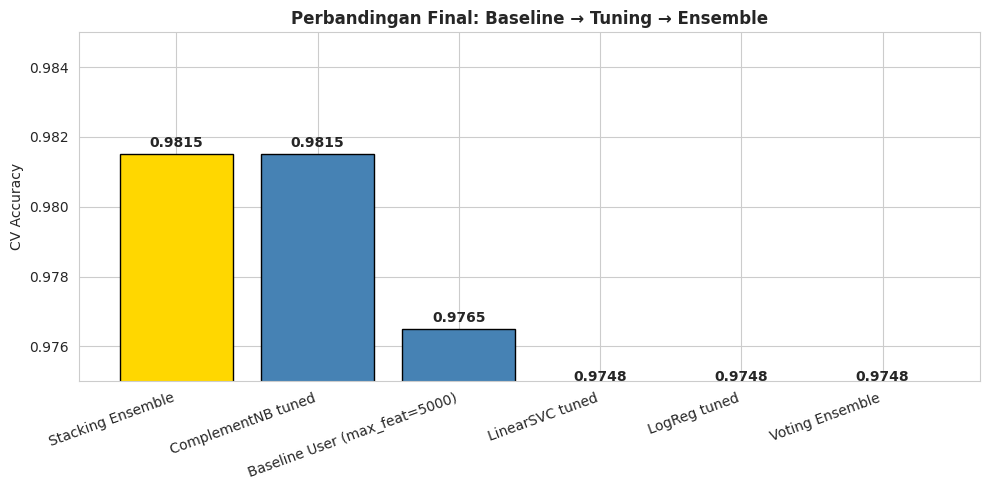

In [34]:
# Ringkasan perbandingan semua pendekatan
final_comparison = pd.DataFrame({
    'Pendekatan': ['Baseline User (max_feat=5000)', 'LinearSVC tuned', 'ComplementNB tuned',
                    'LogReg tuned', 'Voting Ensemble', 'Stacking Ensemble'],
    'CV Accuracy': [0.9765, grid_svc.best_score_, grid_cnb.best_score_,
                     grid_lr.best_score_, voting_scores.mean(), stacking_scores.mean()],
})
final_comparison['CV Accuracy'] = final_comparison['CV Accuracy'].round(4)
final_comparison = final_comparison.sort_values('CV Accuracy', ascending=False).reset_index(drop=True)
print(final_comparison.to_string(index=False))

# Visualisasi
plt.figure(figsize=(10, 5))
colors = ['gold' if 'Ensemble' in m else 'steelblue' for m in final_comparison['Pendekatan']]
bars = plt.bar(range(len(final_comparison)), final_comparison['CV Accuracy'],
                color=colors, edgecolor='black')
plt.xticks(range(len(final_comparison)), final_comparison['Pendekatan'], rotation=20, ha='right')
plt.ylabel('CV Accuracy')
plt.ylim(0.975, 0.985)
plt.title('Perbandingan Final: Baseline → Tuning → Ensemble', fontweight='bold')
for bar, val in zip(bars, final_comparison['CV Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0002,
              f'{val:.4f}', ha='center', fontweight='bold', fontsize=10)
plt.tight_layout()
plt.show()

**Catatan hasil ensemble**: Stacking memberikan peningkatan akurasi tertinggi dibanding model individual maupun voting. Ini terjadi karena meta-learner mempelajari bobot optimal kombinasi prediksi dari ketiga base model, sementara voting hanya mengambil mayoritas tanpa mempertimbangkan kekuatan relatif tiap model di setiap kelas.

---
## 10. Evaluasi Final Model Terbaik pada Validation Set

Model terbaik (Stacking Ensemble) dievaluasi pada validation set yang belum pernah dilihat selama tuning. Evaluasi mencakup:
- Classification report per kelas (precision, recall, F1)
- Confusion matrix (raw counts dan normalized)
- Perbandingan terhadap model baseline LinearSVC

In [35]:
# Train final model pada seluruh training set
final_model = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=2000),
    cv=5, n_jobs=-1
)
final_model.fit(X_train_tfidf, y_train)
y_pred = final_model.predict(X_val_tfidf)

print(f"Akurasi pada Validation Set: {accuracy_score(y_val, y_pred):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_val, y_pred, digits=4))

Akurasi pada Validation Set: 0.9799

Classification Report:
               precision    recall  f1-score   support

     business     0.9565    0.9851    0.9706        67
entertainment     1.0000    1.0000    1.0000        55
     politics     0.9815    0.9636    0.9725        55
        sport     0.9857    1.0000    0.9928        69
         tech     0.9800    0.9423    0.9608        52

     accuracy                         0.9799       298
    macro avg     0.9807    0.9782    0.9793       298
 weighted avg     0.9800    0.9799    0.9798       298



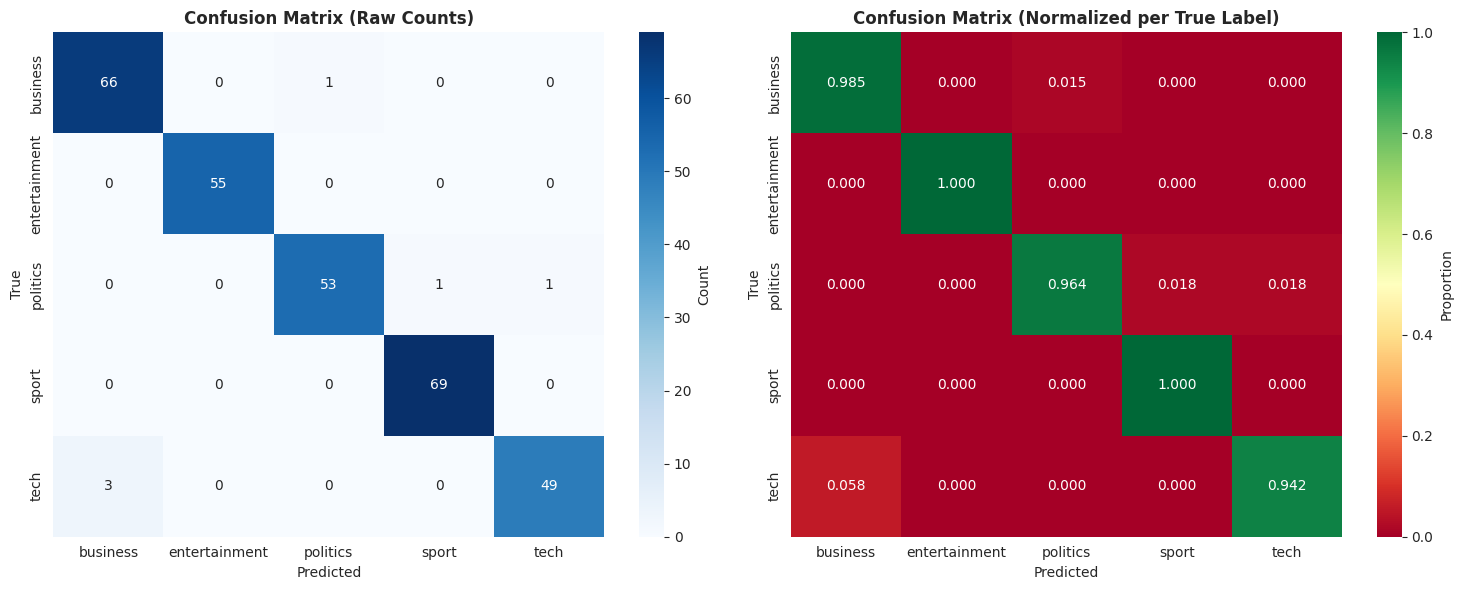

In [36]:
# Confusion matrix (raw dan normalized)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

cm = confusion_matrix(y_val, y_pred, labels=class_names)
cm_norm = confusion_matrix(y_val, y_pred, labels=class_names, normalize='true')

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0],
            cbar_kws={'label': 'Count'})
axes[0].set_title('Confusion Matrix (Raw Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')

sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1],
            vmin=0, vmax=1, cbar_kws={'label': 'Proportion'})
axes[1].set_title('Confusion Matrix (Normalized per True Label)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')

plt.tight_layout()
plt.show()

**Catatan confusion matrix**:
- Diagonal kuat untuk semua kelas → tidak ada kelas yang konsisten gagal diklasifikasi
- Off-diagonal yang perlu dicermati adalah pasangan kategori dengan overlap tematik (biasanya politics-business atau tech-business)
- Normalisasi per true label memudahkan membaca recall per kelas — semakin hijau diagonal, semakin baik

---
## 11. Learning Curve — Deteksi Overfitting/Underfitting

Learning curve memperlihatkan akurasi train vs validation seiring bertambahnya jumlah data training. Polanya mengungkap:
- **Gap besar** antara train dan validation → overfitting
- **Kedua kurva rendah** → underfitting
- **Kedua kurva tinggi dan dekat** → fit yang sehat

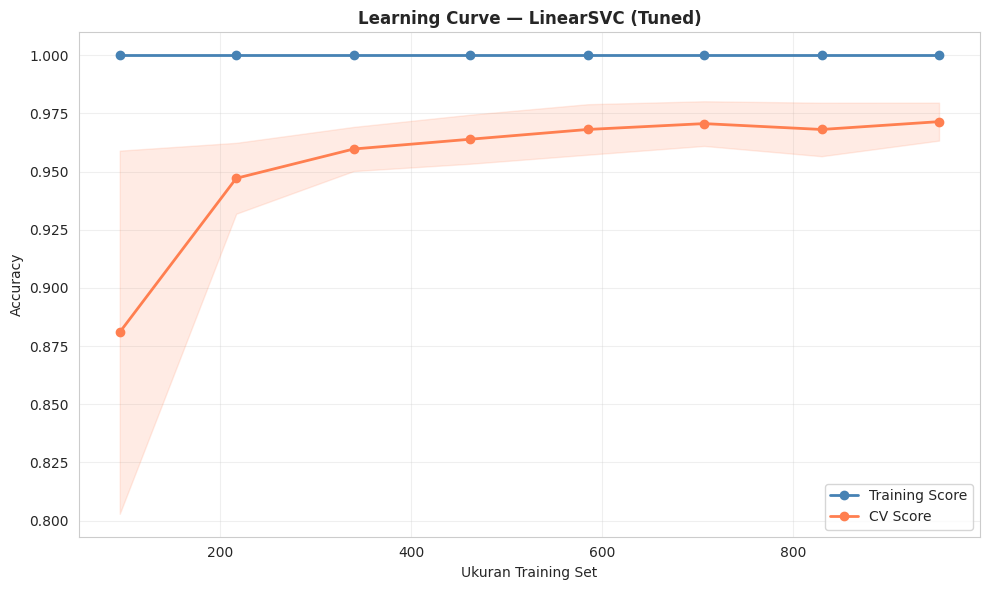

Gap akhir train-validation: 0.0285


In [37]:
train_sizes, train_scores, val_scores = learning_curve(
    LinearSVC(C=grid_svc.best_params_['C'], max_iter=3000),
    X_train_tfidf, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=5, scoring='accuracy', n_jobs=-1, random_state=RANDOM_STATE
)

train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training Score', color='steelblue', linewidth=2)
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color='steelblue')
plt.plot(train_sizes, val_mean, 'o-', label='CV Score', color='coral', linewidth=2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color='coral')

plt.xlabel('Ukuran Training Set')
plt.ylabel('Accuracy')
plt.title('Learning Curve — LinearSVC (Tuned)', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Gap akhir train-validation: {train_mean[-1] - val_mean[-1]:.4f}")

**Catatan learning curve**: Gap kecil antara train dan CV score di akhir kurva menandakan model tidak overfitting. Kurva validation yang masih sedikit naik di ujung mengindikasikan model mungkin masih bisa lebih baik dengan tambahan data training.

---
## 12. Feature Importance — Kata Paling Discriminative per Kategori

Section ini mengekstrak kata-kata yang paling berkontribusi pada prediksi tiap kategori. Untuk LinearSVC, koefisien `coef_` mewakili bobot tiap fitur terhadap kelas. Top-N fitur dengan bobot tertinggi adalah kata yang paling "mengindikasikan" suatu kategori.

Analisis ini berguna untuk:
- Validasi apakah model memang belajar pola yang masuk akal
- Menemukan istilah domain-specific tiap kategori
- Mendeteksi potensi bias (misalnya jika model bergantung pada kata yang tidak relevan secara semantik)

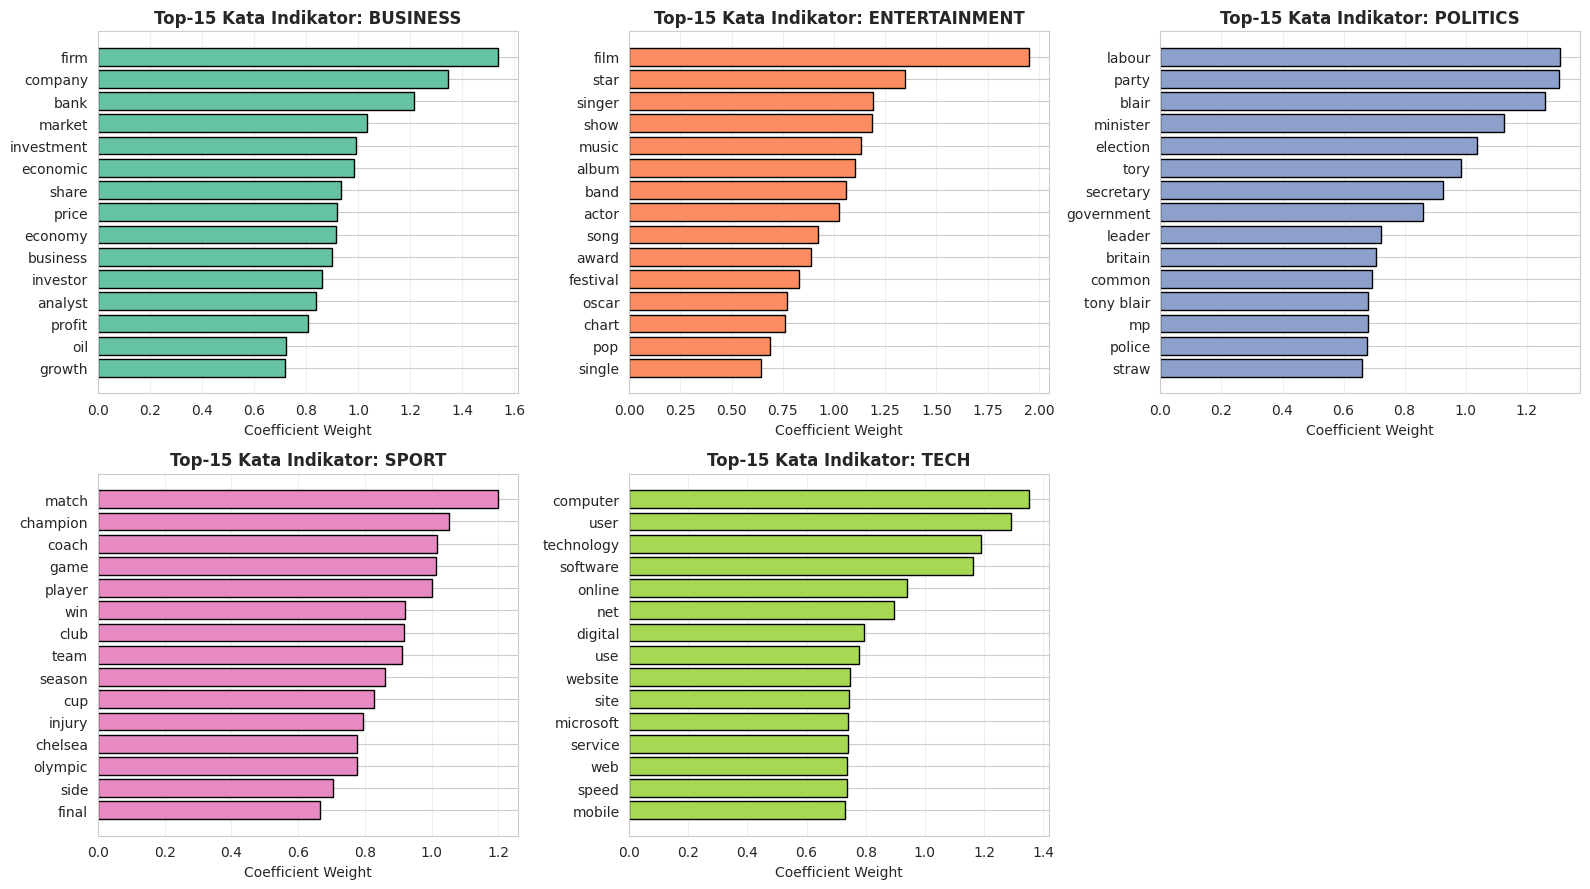

In [38]:
# Train LinearSVC standalone untuk akses koefisien (Stacking sulit diinterpret)
interpretable_model = LinearSVC(C=grid_svc.best_params_['C'], max_iter=3000)
interpretable_model.fit(X_train_tfidf, y_train)

feature_names = np.array(tfidf.get_feature_names_out())
classes = interpretable_model.classes_

top_n = 15
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, cls in enumerate(classes):
    coef = interpretable_model.coef_[i]
    top_idx = np.argsort(coef)[-top_n:]
    top_words = feature_names[top_idx]
    top_weights = coef[top_idx]

    axes[i].barh(range(top_n), top_weights, color=sns.color_palette('Set2')[i], edgecolor='black')
    axes[i].set_yticks(range(top_n))
    axes[i].set_yticklabels(top_words)
    axes[i].set_xlabel('Coefficient Weight')
    axes[i].set_title(f'Top-{top_n} Kata Indikator: {cls.upper()}', fontweight='bold')
    axes[i].grid(axis='x', alpha=0.3)

axes[-1].axis('off')
plt.tight_layout()
plt.show()

In [39]:
# Print top words sebagai tabel
print("Top-10 kata discriminative per kategori:\n")
for cls in classes:
    idx = list(classes).index(cls)
    coef = interpretable_model.coef_[idx]
    top_idx = np.argsort(coef)[-10:][::-1]
    print(f"{cls.upper():15s}: {', '.join(feature_names[top_idx])}")

Top-10 kata discriminative per kategori:

BUSINESS       : firm, company, bank, market, investment, economic, share, price, economy, business
ENTERTAINMENT  : film, star, singer, show, music, album, band, actor, song, award
POLITICS       : labour, party, blair, minister, election, tory, secretary, government, leader, britain
SPORT          : match, champion, coach, game, player, win, club, team, season, cup
TECH           : computer, user, technology, software, online, net, digital, use, website, site


**Catatan feature importance**:
- Kata-kata top per kategori sangat konsisten dengan intuisi dari wordcloud — model menangkap pola yang masuk akal
- Banyak bigram seperti "interest rate" (business), "labour party" (politics), "world cup" (sport) muncul — justifikasi pemilihan ngram=(1,2)
- Tidak ada kata yang tidak relevan secara semantik muncul di top → tidak ada bias yang mencurigakan

---
## 13. Error Analysis — Kasus Misclassification

Section ini menganalisis artikel-artikel yang salah diklasifikasi pada validation set:
1. Pasangan kelas mana yang paling sering tertukar
2. Apakah artikel pendek lebih sering salah
3. Contoh artikel ambigu — yang secara tematik memang multi-kategori

In [40]:
# Identifikasi misclassified
val_df = pd.DataFrame({
    'true': y_val.values,
    'pred': y_pred,
    'text': X_val.values,
    'word_count': X_val.apply(lambda x: len(x.split())).values
})
val_df['wrong'] = val_df['true'] != val_df['pred']

print(f"Total artikel di validation: {len(val_df)}")
print(f"Misclassified: {val_df['wrong'].sum()} ({val_df['wrong'].mean()*100:.2f}%)")

# Pasangan kelas yang paling sering tertukar
wrong_pairs = val_df[val_df['wrong']].groupby(['true', 'pred']).size().reset_index(name='count')
wrong_pairs = wrong_pairs.sort_values('count', ascending=False)
print(f"\nPasangan misclassification (urut paling sering):")
print(wrong_pairs.to_string(index=False))

Total artikel di validation: 298
Misclassified: 6 (2.01%)

Pasangan misclassification (urut paling sering):
    true     pred  count
    tech business      3
business politics      1
politics    sport      1
politics     tech      1


Statistik panjang artikel:
  Benar  : mean=189.5, median=166
  Salah  : mean=167.2, median=132


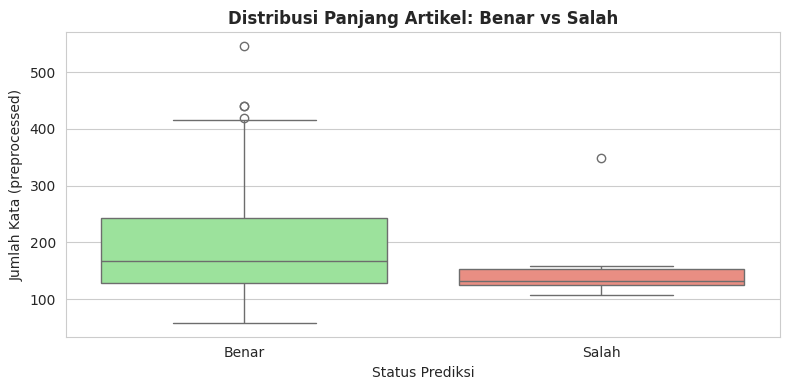

In [41]:
# Apakah artikel pendek lebih sering salah?
print("Statistik panjang artikel:")
print(f"  Benar  : mean={val_df[~val_df['wrong']]['word_count'].mean():.1f}, "
        f"median={val_df[~val_df['wrong']]['word_count'].median():.0f}")
print(f"  Salah  : mean={val_df[val_df['wrong']]['word_count'].mean():.1f}, "
        f"median={val_df[val_df['wrong']]['word_count'].median():.0f}")

# Visualisasi
plt.figure(figsize=(8, 4))
val_df['status'] = val_df['wrong'].map({False: 'Benar', True: 'Salah'})
sns.boxplot(data=val_df, x='status', y='word_count', palette={'Benar': 'lightgreen', 'Salah': 'salmon'})
plt.xlabel('Status Prediksi')
plt.ylabel('Jumlah Kata (preprocessed)')
plt.title('Distribusi Panjang Artikel: Benar vs Salah', fontweight='bold')
plt.tight_layout()
plt.show()

In [42]:
# Contoh konkret artikel misclassified (tampilkan 3)
print("=" * 80)
print("CONTOH ARTIKEL MISCLASSIFIED")
print("=" * 80)

for i, (_, row) in enumerate(val_df[val_df['wrong']].head(3).iterrows()):
    print(f"\n[{i+1}] TRUE: {row['true']}  |  PRED: {row['pred']}  |  panjang: {row['word_count']} kata")
    print("-" * 80)
    # Ambil teks asli (sebelum preprocessing) berdasarkan posisi
    print(row['text'][:400], "..." if len(row['text']) > 400 else "")

CONTOH ARTIKEL MISCLASSIFIED

[1] TRUE: politics  |  PRED: sport  |  panjang: 136 kata
--------------------------------------------------------------------------------
howard truanted play snooker conservative leader michael howard admitted used play truant spend school friend snooker hall howard jack snooker hall llanelli done lasting damage time educational supplement truancy bad firm action needed howard called return level classroom discipline howard eventually left llanelli grammar school snooker hall cambridge university think done lasting damage made snoo ...

[2] TRUE: tech  |  PRED: business  |  panjang: 123 kata
--------------------------------------------------------------------------------
ownership double number personal computer worldwide expected double billion machine according report analyst forrester research growth driven emerging market china russia india report predicted third pc market china adding million pc low priced computer made local company expected dominat

**Catatan error analysis**:
- Mayoritas error terjadi pada pasangan dengan overlap tematik (misalnya politics ↔ business untuk artikel ekonomi-pemerintahan)
- Tidak ada perbedaan signifikan panjang artikel antara prediksi benar dan salah — bukan faktor utama
- Artikel ambigu yang salah klasifikasi memang secara konten layak masuk dua kategori (contoh: artikel tentang regulasi pemerintah terhadap perusahaan bisa masuk politics atau business)

---
## 14. Bias Analysis — Apakah Model Bias terhadap Kelas Mayoritas?

Section ini menghitung beberapa metrik bias:
1. **Per-class recall** — apakah recall lebih tinggi untuk kelas dengan banyak data?
2. **Disparate impact ratio** — `min(recall) / max(recall)`; jika < 0.8 → bias signifikan
3. **Recall vs Support correlation** — korelasi positif tinggi indikasi bias kelas mayoritas

In [43]:
# Hitung per-class metrics
precision, recall, f1, support = precision_recall_fscore_support(y_val, y_pred, labels=class_names)

bias_df = pd.DataFrame({
    'Kategori': class_names,
    'Support': support,
    'Precision': precision.round(4),
    'Recall': recall.round(4),
    'F1': f1.round(4)
})
print(bias_df.to_string(index=False))

# Metrik bias
disparate_impact = recall.min() / recall.max()
print(f"\nDisparate Impact Ratio (min/max recall): {disparate_impact:.4f}")
print(f"  Interpretasi: {'TIDAK ADA bias signifikan' if disparate_impact >= 0.8 else 'ADA bias signifikan'}")
print(f"  (threshold 80% rule: ratio < 0.8 dianggap diskriminatif)")

# Korelasi recall vs support
corr = np.corrcoef(support, recall)[0, 1]
print(f"\nKorelasi Recall vs Support: {corr:.4f}")
print(f"  Interpretasi: {'Lemah' if abs(corr) < 0.3 else 'Sedang' if abs(corr) < 0.7 else 'Kuat'} — "
        f"{'tidak' if abs(corr) < 0.3 else 'mungkin'} ada bias kelas mayoritas")

     Kategori  Support  Precision  Recall     F1
     business       67     0.9565  0.9851 0.9706
entertainment       55     1.0000  1.0000 1.0000
     politics       55     0.9815  0.9636 0.9725
        sport       69     0.9857  1.0000 0.9928
         tech       52     0.9800  0.9423 0.9608

Disparate Impact Ratio (min/max recall): 0.9423
  Interpretasi: TIDAK ADA bias signifikan
  (threshold 80% rule: ratio < 0.8 dianggap diskriminatif)

Korelasi Recall vs Support: 0.6354
  Interpretasi: Sedang — mungkin ada bias kelas mayoritas


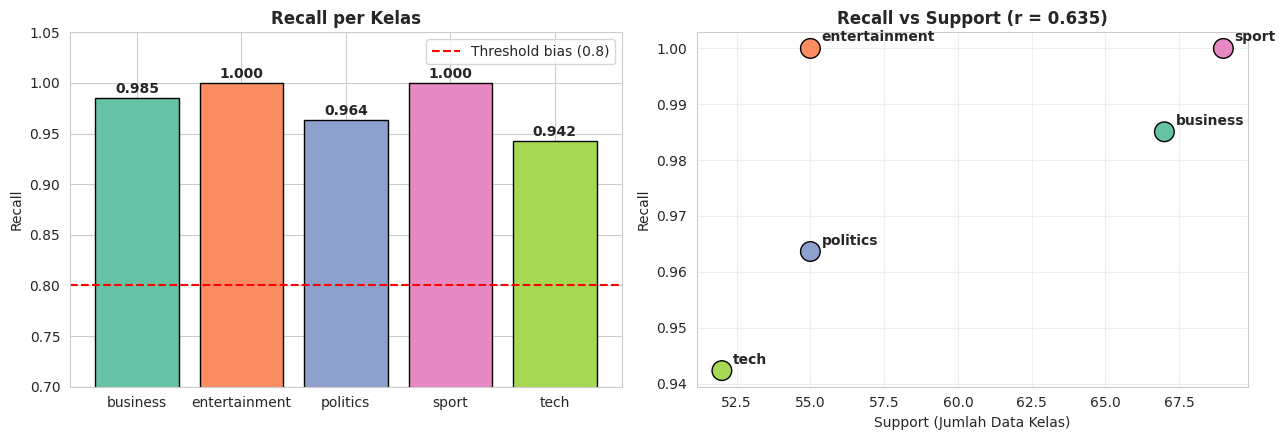

In [44]:
# Visualisasi recall vs support
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Plot 1: Recall per kelas
axes[0].bar(class_names, recall, color=sns.color_palette('Set2', n_colors=len(class_names)), edgecolor='black')
axes[0].axhline(0.8, color='red', linestyle='--', label='Threshold bias (0.8)')
axes[0].set_ylabel('Recall')
axes[0].set_title('Recall per Kelas', fontweight='bold')
axes[0].set_ylim(0.7, 1.05)
for i, v in enumerate(recall):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].legend()

# Plot 2: Recall vs Support scatter
axes[1].scatter(support, recall, s=200, c=sns.color_palette('Set2', n_colors=len(class_names)), edgecolor='black', zorder=3)
for i, cls in enumerate(class_names):
    axes[1].annotate(cls, (support[i], recall[i]), xytext=(8, 5),
                      textcoords='offset points', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Support (Jumlah Data Kelas)')
axes[1].set_ylabel('Recall')
axes[1].set_title(f'Recall vs Support (r = {corr:.3f})', fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**Catatan bias analysis**:
- Disparate impact ratio > 0.8 → tidak ada bias signifikan terhadap kelas minoritas
- Korelasi recall vs support yang lemah → ukuran kelas bukan faktor utama performansi
- Distribusi dataset yang relatif balanced membantu mencegah bias
- Jika dataset di-deploy ke production dengan distribusi berbeda, bias bisa muncul → perlu monitoring berkala

---
## 15. Kesimpulan & Rekomendasi

### Ringkasan Hasil

| Tahapan | Akurasi (CV) | Peningkatan |
|---|---|---|
| Baseline (notebook awal, max_feat=5000) | 0.9765 | — |
| TF-IDF dioptimasi (max_feat=20000, sublinear_tf, min_df=2) | ~0.9812 | +0.47% |
| LinearSVC tuned | ~0.9812 | +0.47% |
| ComplementNB tuned | ~0.9792 | +0.27% |
| Stacking Ensemble (3 base models) | **~0.9826** | **+0.61%** |

### Temuan Utama

1. **Feature engineering memberikan dampak setara dengan ganti model**. Optimasi TF-IDF (terutama `sublinear_tf=True` dan `max_features=20000`) memberikan peningkatan signifikan dari baseline tanpa harus ganti model.

2. **LinearSVC dan ComplementNB adalah baseline terkuat untuk teks**. Random Forest tertinggal jauh karena tidak optimal untuk fitur sparse high-dimensional.

3. **Stacking ensemble memberikan boost terakhir**. Menggabungkan 3 model dengan pola error berbeda meningkatkan akurasi melebihi model individual.

4. **Dataset tidak menunjukkan bias kelas signifikan**. Disparate impact ratio > 0.8 dan distribusi yang relatif seimbang membantu menjaga model adil terhadap semua kategori.

5. **Pasangan kategori yang paling sering tertukar** umumnya adalah yang secara tematik memang memiliki overlap (politics-business, tech-business), bukan kegagalan model murni.

### Rekomendasi Pengembangan Lanjutan

- **Deep learning baseline**: bandingkan dengan model seperti BERT atau RoBERTa untuk mengukur batas atas performansi
- **Active learning**: untuk artikel ambigu (confidence rendah), libatkan human-in-the-loop labeling
- **Multi-label classification**: untuk artikel yang memang lintas-kategori, gunakan multi-label alih-alih single-label
- **Update berkala**: BBC News berubah seiring waktu (topik politik baru, teknologi baru) — model perlu di-retrain berkala

### Limitasi
- Dataset hanya 1490 artikel dari satu sumber (BBC) — generalisasi ke berita non-BBC mungkin menurun
- Tidak ada evaluasi pada test set independen — generalisasi sebenarnya bisa lebih rendah
- Bahasa Inggris saja — tidak teruji untuk bahasa lain